# 1. Carga de datos

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("oussamamoussa/foot-ball-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'foot-ball-dataset' dataset.
Path to dataset files: /kaggle/input/foot-ball-dataset


In [2]:
dataset_path = path

In [3]:
import os

dataset_path = path

print("Carpeta raíz:")
print(dataset_path)

print("\nContenido:")
for item in os.listdir(dataset_path):
    item_path = os.path.join(dataset_path, item)

    if os.path.isdir(item_path):
        print("📁", item)
    else:
        print("📄", item)

Carpeta raíz:
/kaggle/input/foot-ball-dataset

Contenido:
📄 data.yaml
📁 valid
📁 test
📁 train


In [4]:
for root, dirs, files in os.walk(dataset_path):

    nivel = root.replace(dataset_path, "").count(os.sep)

    if nivel > 3:
        continue

    indent = "    " * nivel

    print(f"{indent}📁 {os.path.basename(root)}/")

    for file in files[:5]:
        print(f"{indent}    📄 {file}")

📁 foot-ball-dataset/
    📄 data.yaml
    📁 valid/
        📁 labels/
            📄 ds40_54745b_9_7_png_jpg.rf.21e8f9ff42d3bdf1b50614d1c770a706.txt
            📄 ds22_798b45_1_2_png_jpg.rf.be8321eb76a48e98ca1f7fe8815d63d2.txt
            📄 ds46_42ba34_1_3_png_jpg.rf.c2d44b0c8039c5e83bffbc689de4ae4a.txt
            📄 ds47_c01561_1_6_png_jpg.rf.52cffc5cae1ccb3af8a19e3723f0a07f.txt
            📄 ds71_300_jpg.rf.069ab39bde6ea4d8d185417d9acf9559.txt
        📁 images/
            📄 ds52_00-05-11-00-05-43-000750_jpg.rf.31c0fdf47eaa91b898289a2f239d144e.jpg
            📄 ds09_744b27_7_7_png_jpg.rf.d2a6cfe04afa5de2c538854c08c61507.jpg
            📄 ds37_patch_20240616_100648_760993_jpg.rf.12b51fce6f7193d007bed088f04e65c1.jpg
            📄 ds31_744b27_7_1_png_jpg.rf.b9ddc59108c5fa8d5a7d3e1d19cfb12a.jpg
            📄 ds55_179_jpg.rf.d1a4a8e5ae263ccd3fd627e0f52c77aa.jpg
    📁 test/
        📁 labels/
            📄 ds47_sample_463_jpg.rf.c8a26a6c2f071413321db6f1ff67d1cf.txt
            📄 ds18_798b45_3_

# 2. EDA

## Número de imágenes en el dataset

In [5]:
from pathlib import Path

dataset_path = Path(path)

valid_ext = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tiff",
    ".webp"
}

image_paths = [
    p for p in dataset_path.rglob("*")
    if p.suffix.lower() in valid_ext
]

print("Cantidad total de imágenes:", len(image_paths))

print("\nPrimeras imágenes encontradas:")
for img in image_paths[:10]:
    print(img)

Cantidad total de imágenes: 53445

Primeras imágenes encontradas:
/kaggle/input/foot-ball-dataset/train/images/ds60_225_jpg.rf.ad3cde6224192f247aaf60e860ecaa22.jpg
/kaggle/input/foot-ball-dataset/train/images/ds44_08fd33_0_1_png_jpg.rf.f0d22f500ee445b5d1b175ff7516e912.jpg
/kaggle/input/foot-ball-dataset/train/images/ds58_1_720p_000575_jpg.rf.bf514c984345a5623424f7ec9c8cdf22.jpg
/kaggle/input/foot-ball-dataset/train/images/ds10_4b770a_3_3_png_jpg.rf.f9b6e0988f6c89638054fe309da46036.jpg
/kaggle/input/foot-ball-dataset/train/images/ds14_08fd33_6_5_png_jpg.rf.dbcb52ee0cacca1ab1bc48dc21fb770e.jpg
/kaggle/input/foot-ball-dataset/train/images/ds56_cd987c_9_8_png_jpg.rf.57d1abf1daac1afc5095758e28a260ed.jpg
/kaggle/input/foot-ball-dataset/train/images/ds12_1606b0e6_1_163_play_png.rf.4bc283b306c7d627dab1b70228148568.jpg
/kaggle/input/foot-ball-dataset/train/images/ds45_744b27_5_3_png_jpg.rf.d2cbfd96678c1ddc39f896a9cda6bdf3.jpg
/kaggle/input/foot-ball-dataset/train/images/ds31_08fd33_6_3_png_jpg.

## Imágenes aleatorias

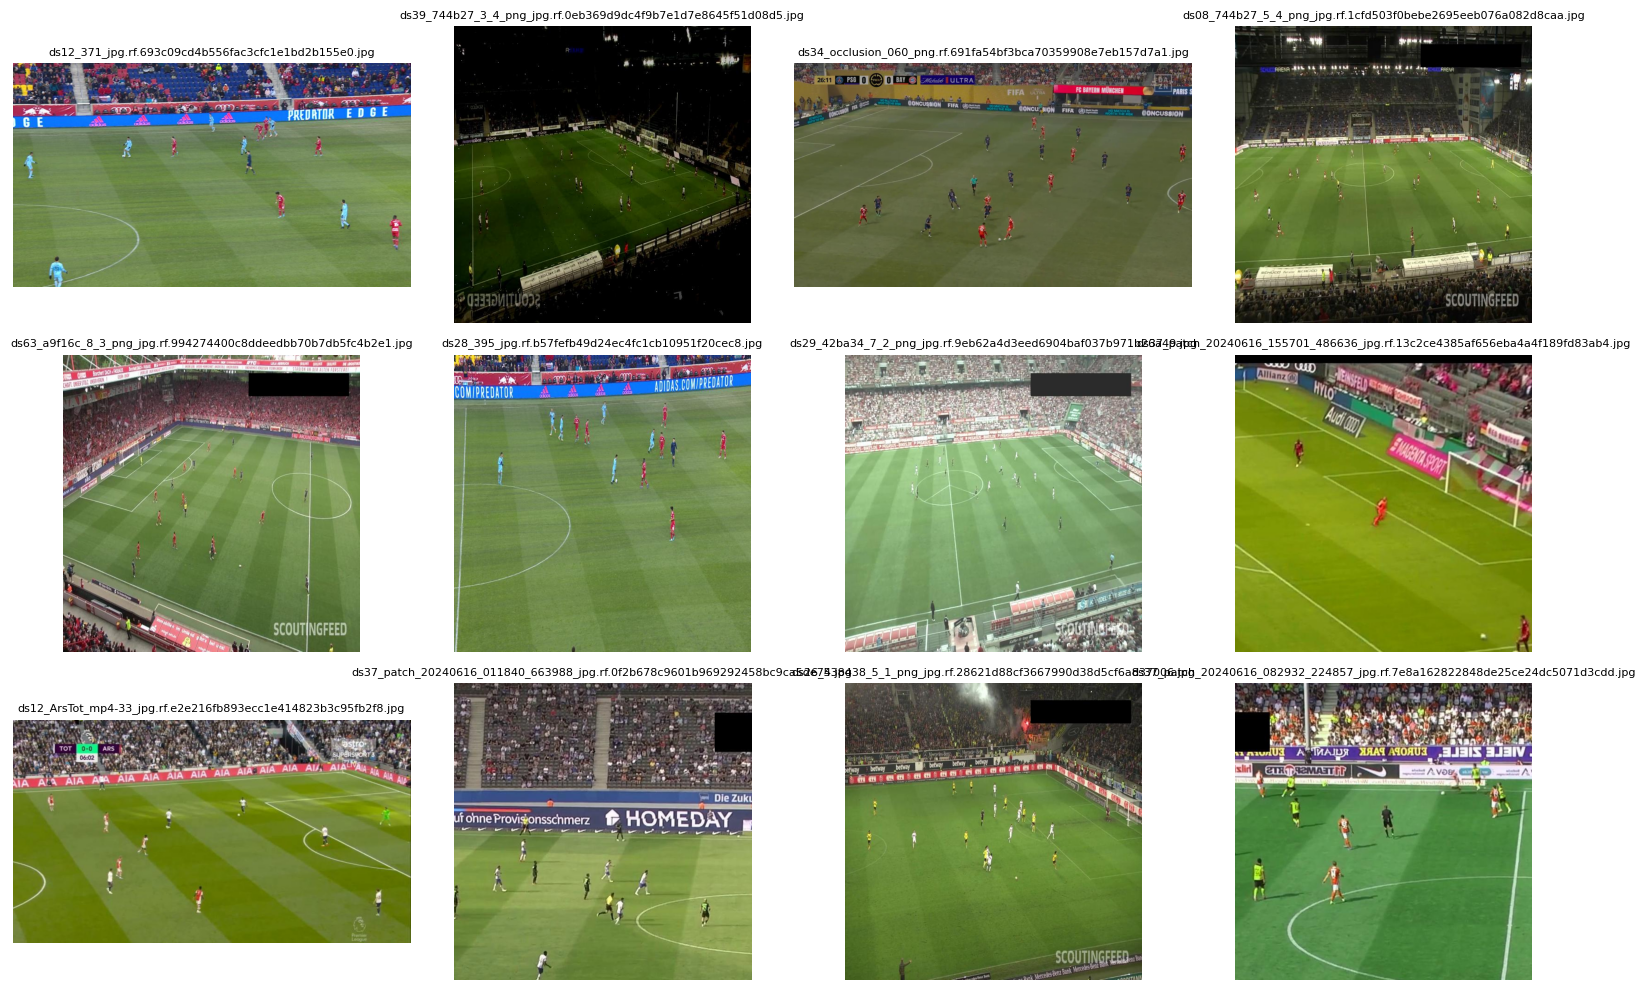

In [6]:
import random
import cv2
import matplotlib.pyplot as plt

n_images = 12

selected = random.sample(
    image_paths,
    min(n_images, len(image_paths))
)

fig, axes = plt.subplots(3, 4, figsize=(16, 10))

axes = axes.flatten()

for ax, img_path in zip(axes, selected):

    img = cv2.imread(str(img_path))

    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ax.imshow(img)
        ax.set_title(img_path.name, fontsize=8)

    ax.axis("off")

plt.tight_layout()
plt.show()

## Formato / Ancho / Alto / Relación de aspecto / Número de píxels

In [7]:
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm
from math import gcd

data = []

corrupted_images = []

for img_path in tqdm(image_paths):

    try:

        with Image.open(img_path) as img:

            width, height = img.size
            img_format = img.format
            mode = img.mode

            g = gcd(width, height)

            aspect_ratio = f"{width // g}:{height // g}"

            data.append({
                "path": str(img_path),
                "filename": img_path.name,
                "folder": img_path.parent.name,
                "extension": img_path.suffix.lower(),
                "format": img_format,
                "width": width,
                "height": height,
                "aspect_ratio": aspect_ratio,
                "pixels": width * height,
                "mode": mode
            })

    except Exception as e:

        corrupted_images.append(
            (str(img_path), str(e))
        )

df_images = pd.DataFrame(data)

print("Imágenes analizadas:", len(df_images))
print("Imágenes con problemas:", len(corrupted_images))

df_images.head()

  0%|          | 0/53445 [00:00<?, ?it/s]

Imágenes analizadas: 53445
Imágenes con problemas: 0


,path,filename,folder,extension,format,width,height,aspect_ratio,pixels,mode
0,/kaggle/input/foot-ball-dataset/train/images/d...,ds60_225_jpg.rf.ad3cde6224192f247aaf60e860ecaa...,images,.jpg,JPEG,640,640,1:1,409600,RGB
1,/kaggle/input/foot-ball-dataset/train/images/d...,ds44_08fd33_0_1_png_jpg.rf.f0d22f500ee445b5d1b...,images,.jpg,JPEG,640,640,1:1,409600,RGB
2,/kaggle/input/foot-ball-dataset/train/images/d...,ds58_1_720p_000575_jpg.rf.bf514c984345a5623424...,images,.jpg,JPEG,1280,720,16:9,921600,RGB
3,/kaggle/input/foot-ball-dataset/train/images/d...,ds10_4b770a_3_3_png_jpg.rf.f9b6e0988f6c8963805...,images,.jpg,JPEG,640,640,1:1,409600,RGB
4,/kaggle/input/foot-ball-dataset/train/images/d...,ds14_08fd33_6_5_png_jpg.rf.dbcb52ee0cacca1ab1b...,images,.jpg,JPEG,640,640,1:1,409600,RGB


In [8]:
df_images.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53445 entries, 0 to 53444
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   path          53445 non-null  object
 1   filename      53445 non-null  object
 2   folder        53445 non-null  object
 3   extension     53445 non-null  object
 4   format        53445 non-null  object
 5   width         53445 non-null  int64 
 6   height        53445 non-null  int64 
 7   aspect_ratio  53445 non-null  object
 8   pixels        53445 non-null  int64 
 9   mode          53445 non-null  object
dtypes: int64(3), object(7)
memory usage: 4.1+ MB


In [9]:
df_images.describe()

,width,height,pixels
count,53445.000000,53445.000000,5.344500e+04
mean,733.802489,687.923117,5.503921e+05
std,293.053666,188.594883,5.885146e+05
min,576.000000,333.000000,2.131200e+05
25%,640.000000,640.000000,4.096000e+05
50%,640.000000,640.000000,4.096000e+05
75%,640.000000,640.000000,4.096000e+05
max,3840.000000,2160.000000,8.294400e+06


## Cantidad total de imágenes

In [10]:
print(f"Total de imágenes: {len(df_images):,}")

Total de imágenes: 53,445


In [11]:
df_images["folder"].value_counts()

,count
folder,
images,53445


In [12]:
from pathlib import Path

dataset_path = Path(path)

splits = ["train", "valid", "test"]

valid_ext = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

for split in splits:

    images_dir = dataset_path / split / "images"

    images = [
        img for img in images_dir.iterdir()
        if img.suffix.lower() in valid_ext
    ]

    print(f"{split.upper():<6}: {len(images):,} imágenes")

TRAIN : 46,511 imágenes
VALID : 4,757 imágenes
TEST  : 2,177 imágenes


In [13]:
summary = []

for split in splits:

    images_dir = dataset_path / split / "images"
    labels_dir = dataset_path / split / "labels"

    images = [
        img for img in images_dir.iterdir()
        if img.suffix.lower() in valid_ext
    ]

    labels = list(
        labels_dir.glob("*.txt")
    )

    summary.append({
        "Conjunto": split,
        "Imagenes": len(images),
        "Labels": len(labels)
    })

df_splits = pd.DataFrame(summary)

df_splits

,Conjunto,Imagenes,Labels
0,train,46511,46511
1,valid,4757,4757
2,test,2177,2177


## Formato de imágenes

In [14]:
format_counts = df_images["extension"].value_counts()
display(format_counts)

,count
extension,
.jpg,53445


## Resolución de las imágenes

In [15]:
resolution_counts = (df_images.groupby(["width", "height"]).size().sort_values(ascending=False))
resolution_counts.head(10)

,,0
width,height,
640,640,45258
1280,1280,3464
960,540,1882
1280,720,1107
1920,1080,432
576,576,372
1024,576,222
3840,2160,204
640,360,183


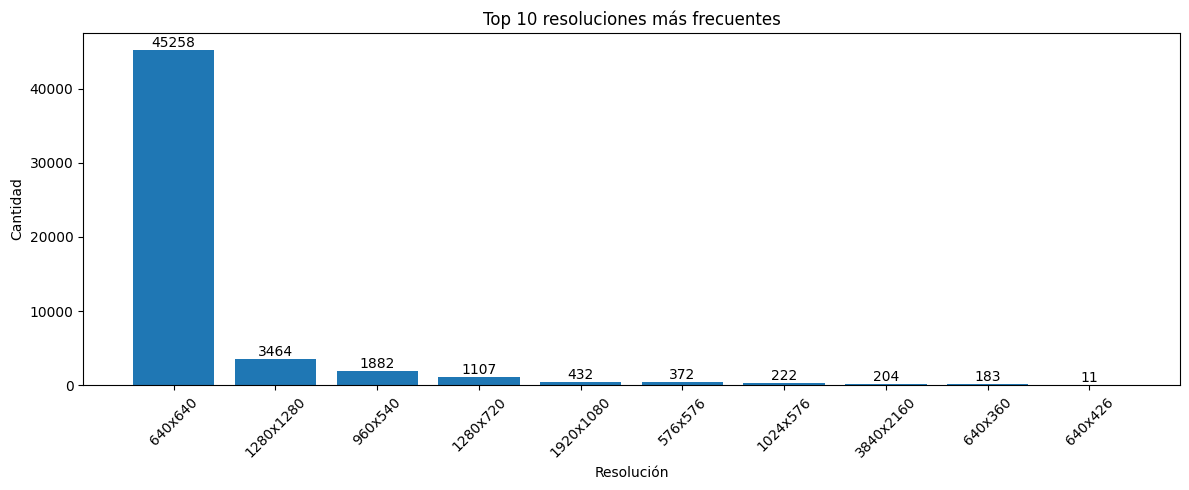

In [16]:
top_resolutions = resolution_counts.head(10)

labels = [
    f"{w}x{h}"
    for w, h in top_resolutions.index
]

plt.figure(figsize=(12, 5))

bars = plt.bar(
    labels,
    top_resolutions.values
)

for bar in bars:

    y = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f"{int(y)}",
        ha="center",
        va="bottom"
    )

plt.title("Top 10 resoluciones más frecuentes")
plt.xlabel("Resolución")
plt.ylabel("Cantidad")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Distribución de altos y anchos

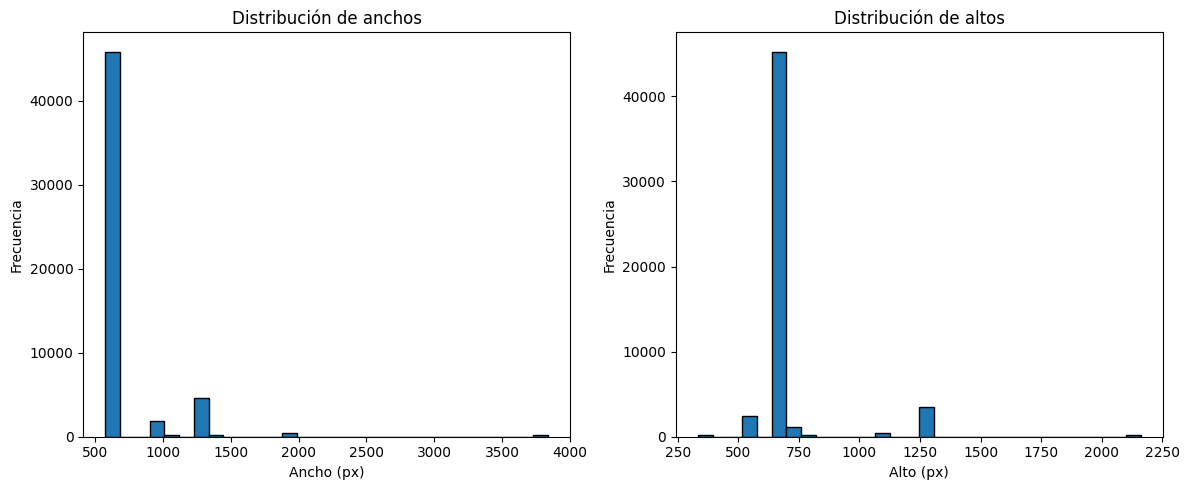

In [17]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.hist(
    df_images["width"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribución de anchos")
plt.xlabel("Ancho (px)")
plt.ylabel("Frecuencia")


plt.subplot(1, 2, 2)

plt.hist(
    df_images["height"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribución de altos")
plt.xlabel("Alto (px)")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

## Relación de aspecto

In [18]:
aspect_counts = df_images["aspect_ratio"].value_counts()

aspect_counts.head(10)

,count
aspect_ratio,
1:1,49094
16:9,4030
320:213,11
1405:787,8
1407:788,6
1412:787,6
706:393,6
1411:787,6
1417:796,6


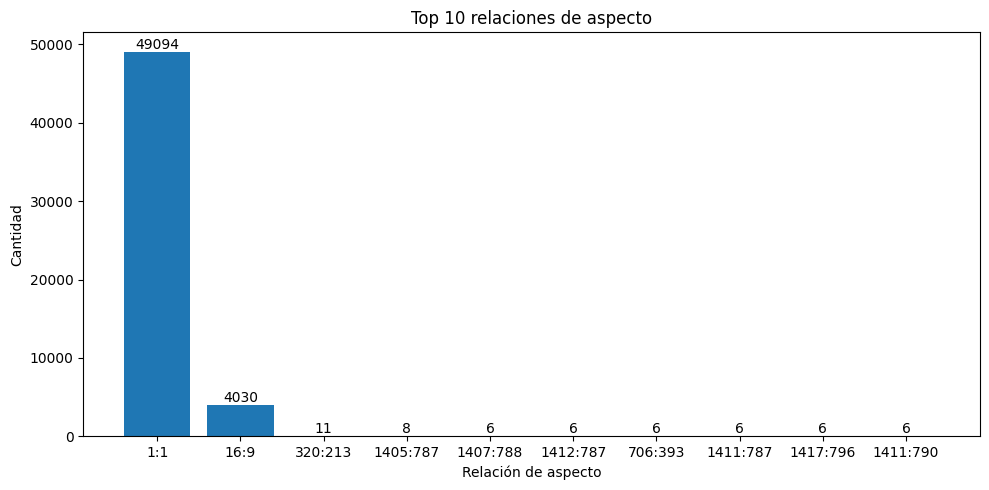

In [19]:
top_aspect = aspect_counts.head(10)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    top_aspect.index,
    top_aspect.values
)

for bar in bars:

    y = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        str(int(y)),
        ha="center",
        va="bottom"
    )

plt.title("Top 10 relaciones de aspecto")

plt.xlabel("Relación de aspecto")
plt.ylabel("Cantidad")

plt.tight_layout()
plt.show()

In [20]:
df_images[["width", "height", "pixels"]].describe()

,width,height,pixels
count,53445.000000,53445.000000,5.344500e+04
mean,733.802489,687.923117,5.503921e+05
std,293.053666,188.594883,5.885146e+05
min,576.000000,333.000000,2.131200e+05
25%,640.000000,640.000000,4.096000e+05
50%,640.000000,640.000000,4.096000e+05
75%,640.000000,640.000000,4.096000e+05
max,3840.000000,2160.000000,8.294400e+06


In [21]:
print("Ancho mínimo:", df_images["width"].min())
print("Ancho máximo:", df_images["width"].max())

print()

print("Alto mínimo:", df_images["height"].min())
print("Alto máximo:", df_images["height"].max())

print()

print(
    "Resolución mediana:",
    int(df_images["width"].median()),
    "x",
    int(df_images["height"].median())
)

Ancho mínimo: 576
Ancho máximo: 3840

Alto mínimo: 333
Alto máximo: 2160

Resolución mediana: 640 x 640


## Detección de imágenes muy pequeñas

In [22]:
min_width = 128
min_height = 128

low_resolution = df_images[
    (df_images["width"] < min_width) |
    (df_images["height"] < min_height)
]

print(
    "Cantidad de imágenes de baja resolución:",
    len(low_resolution)
)

low_resolution.head(20)

Cantidad de imágenes de baja resolución: 0


,path,filename,folder,extension,format,width,height,aspect_ratio,pixels,mode


## Detección de imágenes corruptas

In [23]:
print("Cantidad de imágenes posiblemente corruptas:",len(corrupted_images))

for path_img, error in corrupted_images[:20]:

    print(path_img)
    print(error)
    print("-" * 50)

Cantidad de imágenes posiblemente corruptas: 0


## Visualizar imágenes de distintas resoluciones

In [24]:
smallest = ( df_images.sort_values("pixels").head(4))

largest = (df_images.sort_values("pixels", ascending=False).head(4))

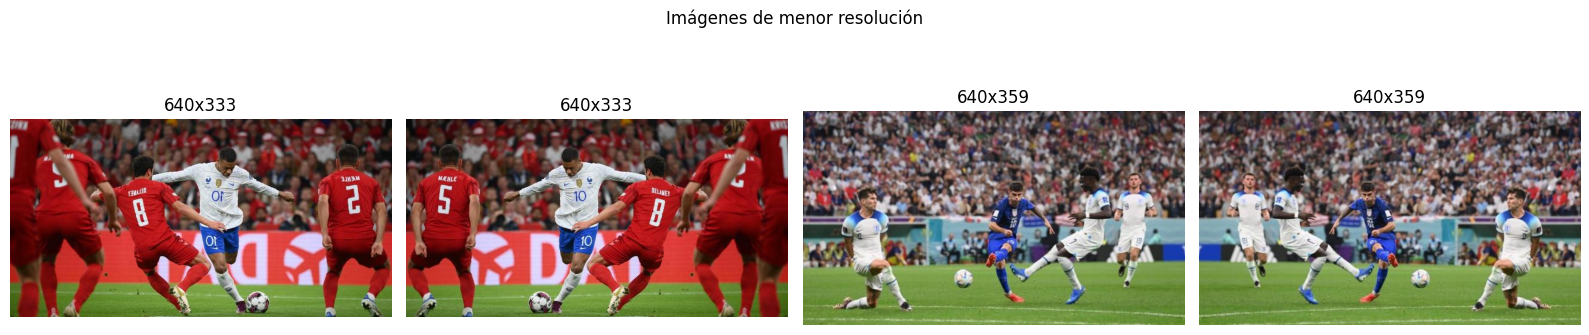

In [25]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (_, row) in zip(axes, smallest.iterrows()):

    img = cv2.imread(row["path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img)

    ax.set_title(
        f'{row["width"]}x{row["height"]}'
    )

    ax.axis("off")

plt.suptitle("Imágenes de menor resolución")

plt.tight_layout()
plt.show()

## Análisis de Color

In [26]:
import numpy as np

sample_size = min(1000,len(image_paths))

sample_images = random.sample(image_paths,sample_size)

In [27]:
mean_colors = []

for img_path in tqdm(sample_images):

    img = cv2.imread(str(img_path))

    if img is None:
        continue

    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    mean_rgb = img.reshape(-1, 3).mean(axis=0)
    mean_colors.append(mean_rgb)

mean_colors = np.array(mean_colors)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [28]:
mean_dataset = mean_colors.mean(axis=0)

print("Promedio R:", mean_dataset[0])
print("Promedio G:", mean_dataset[1])
print("Promedio B:", mean_dataset[2])

Promedio R: 99.55341612945672
Promedio G: 116.24833037488712
Promedio B: 74.3914142828081


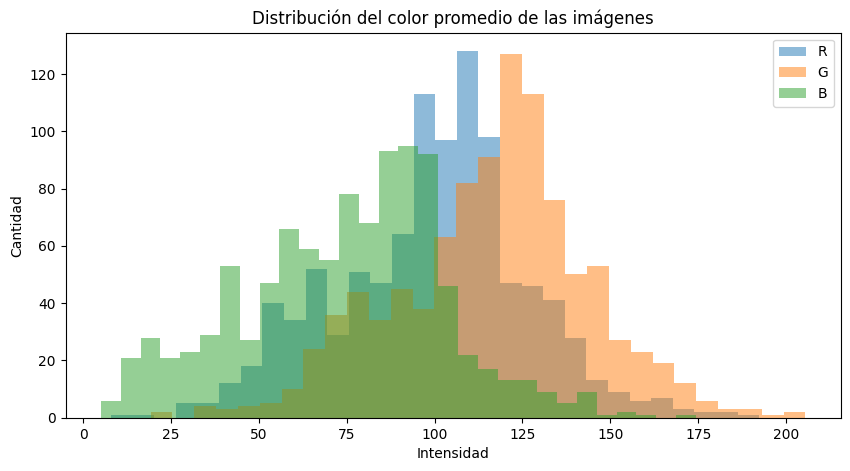

In [29]:
plt.figure(figsize=(10, 5))

plt.hist(mean_colors[:, 0],bins=30,alpha=0.5,label="R")
plt.hist(mean_colors[:, 1],bins=30,alpha=0.5,label="G")
plt.hist(mean_colors[:, 2],bins=30,alpha=0.5,label="B")

plt.xlabel("Intensidad")
plt.ylabel("Cantidad")

plt.title("Distribución del color promedio de las imágenes")
plt.legend()
plt.show()

# 3. Archivo yml

In [30]:
import yaml

yaml_path = dataset_path / "data.yaml"

with open(yaml_path, "r") as f:
    data_yaml = yaml.safe_load(f)

data_yaml

{'names': ['ball', 'goalkeeper', 'player', 'referee'],
 'nc': 4,
 'test': 'test/images',
 'train': 'train/images',
 'val': 'valid/images'}

In [31]:
print("Número de clases:", data_yaml["nc"])
print("Clases:", data_yaml["names"])

Número de clases: 4
Clases: ['ball', 'goalkeeper', 'player', 'referee']


In [32]:
label_example = (dataset_path/ "train"/ "labels")

label_file = next(label_example.glob("*.txt"))

print("Archivo:")
print(label_file)

print("\nContenido:")

with open(label_file, "r") as f:
    print(f.read())

Archivo:
/kaggle/input/foot-ball-dataset/train/labels/ds44_744b27_1_4_png_jpg.rf.43b5dff2b43db5203910de1b81733ccd.txt

Contenido:
2 0.29375 0.34921875 0.0125 0.0390625
2 0.7 0.3875 0.0078125 0.04140625
2 0.8140625 0.4015625 0.0109375 0.040625
2 0.69375 0.39296875 0.009375 0.03984375
2 0.1296875 0.3890625 0.0109375 0.040625
2 0.36875 0.42265625 0.009375 0.0421875
2 0.2609375 0.3828125 0.0078125 0.0375
2 0.22890625 0.3765625 0.009375 0.040625
2 0.8625 0.50703125 0.0140625 0.06015625
2 0.4484375 0.55 0.01640625 0.05078125
2 0.1765625 0.4578125 0.00859375 0.046875
2 0.159375 0.43125 0.0125 0.04765625
2 0.2828125 0.4296875 0.009375 0.04296875
2 0.7140625 0.3859375 0.00625 0.0375
2 0.6796875 0.4515625 0.0109375 0.04921875
2 0.48125 0.41875 0.0125 0.0484375
2 0.83515625 0.4453125 0.01328125 0.05078125
2 0.415625 0.39296875 0.00859375 0.03984375
2 0.503125 0.4515625 0.009375 0.0484375
2 0.85234375 0.5484375 0.01953125 0.06328125
2 0.2265625 0.3546875 0.00859375 0.03359375
0 0.221875 0.36484375

## Bounding Boxes

In [33]:
import pandas as pd
from tqdm.auto import tqdm

annotations = []

for split in splits:

    labels_dir = (dataset_path/ split/ "labels")
    label_files = list(labels_dir.glob("*.txt"))

    for label_file in tqdm(
        label_files,
        desc=f"Leyendo {split}"
    ):

        with open(label_file, "r") as f:

            lines = f.readlines()

        for line in lines:

            parts = line.strip().split()

            if len(parts) != 5:
                continue

            class_id, x, y, w, h = map(float,parts)

            annotations.append({
                "split": split,
                "image_id": label_file.stem,
                "class_id": int(class_id),
                "x_center": x,
                "y_center": y,
                "bbox_width": w,
                "bbox_height": h
            })

df_bbox = pd.DataFrame(annotations)

df_bbox.head()

Leyendo train:   0%|          | 0/46511 [00:00<?, ?it/s]

Leyendo valid:   0%|          | 0/4757 [00:00<?, ?it/s]

Leyendo test:   0%|          | 0/2177 [00:00<?, ?it/s]

,split,image_id,class_id,x_center,y_center,bbox_width,bbox_height
0,train,ds44_744b27_1_4_png_jpg.rf.43b5dff2b43db520391...,2,0.293750,0.349219,0.012500,0.039062
1,train,ds44_744b27_1_4_png_jpg.rf.43b5dff2b43db520391...,2,0.700000,0.387500,0.007812,0.041406
2,train,ds44_744b27_1_4_png_jpg.rf.43b5dff2b43db520391...,2,0.814063,0.401562,0.010937,0.040625
3,train,ds44_744b27_1_4_png_jpg.rf.43b5dff2b43db520391...,2,0.693750,0.392969,0.009375,0.039844
4,train,ds44_744b27_1_4_png_jpg.rf.43b5dff2b43db520391...,2,0.129688,0.389062,0.010937,0.040625


In [34]:
class_names = data_yaml["names"]
class_names

['ball', 'goalkeeper', 'player', 'referee']

In [35]:
df_bbox["class_name"] = (df_bbox["class_id"].map(lambda x: class_names[x]))

In [36]:
df_bbox.head()

,split,image_id,class_id,x_center,y_center,bbox_width,bbox_height,class_name
0,train,ds44_744b27_1_4_png_jpg.rf.43b5dff2b43db520391...,2,0.293750,0.349219,0.012500,0.039062,player
1,train,ds44_744b27_1_4_png_jpg.rf.43b5dff2b43db520391...,2,0.700000,0.387500,0.007812,0.041406,player
2,train,ds44_744b27_1_4_png_jpg.rf.43b5dff2b43db520391...,2,0.814063,0.401562,0.010937,0.040625,player
3,train,ds44_744b27_1_4_png_jpg.rf.43b5dff2b43db520391...,2,0.693750,0.392969,0.009375,0.039844,player
4,train,ds44_744b27_1_4_png_jpg.rf.43b5dff2b43db520391...,2,0.129688,0.389062,0.010937,0.040625,player


## Cantidad de objetos por clase

In [37]:
class_counts = ( df_bbox["class_name"].value_counts())

class_counts

,count
class_name,
player,844941
referee,79680
ball,39489
goalkeeper,24533


In [38]:
class_split = pd.crosstab(df_bbox["class_name"],df_bbox["split"])

class_split

split,test,train,valid
class_name,,,
ball,1555,34412,3522
goalkeeper,959,21546,2028
player,31905,742333,70703
referee,3042,70450,6188


In [39]:
class_split_pct = (class_split.div(class_split.sum(axis=0),axis=1)* 100)

class_split_pct.round(2)

split,test,train,valid
class_name,,,
ball,4.15,3.96,4.27
goalkeeper,2.56,2.48,2.46
player,85.17,85.45,85.76
referee,8.12,8.11,7.51


## Tamaño relativo de bounding box

In [40]:
df_bbox["bbox_area"] = (df_bbox["bbox_width"]* df_bbox["bbox_height"])

In [41]:
df_bbox[["bbox_width","bbox_height","bbox_area"]].describe()

,bbox_width,bbox_height,bbox_area
count,988643.000000,988643.000000,9.886430e+05
mean,0.019243,0.063537,2.152431e-03
std,0.027683,0.041493,2.402221e-02
min,0.000151,0.000076,8.685150e-08
25%,0.010937,0.042188,4.602051e-04
50%,0.014063,0.053125,7.440186e-04
75%,0.021094,0.071875,1.464844e-03
max,1.000000,1.000000,1.000000e+00


In [42]:
invalid_bbox = df_bbox[
    (df_bbox["x_center"] < 0) |
    (df_bbox["x_center"] > 1) |
    (df_bbox["y_center"] < 0) |
    (df_bbox["y_center"] > 1) |
    (df_bbox["bbox_width"] <= 0) |
    (df_bbox["bbox_width"] > 1) |
    (df_bbox["bbox_height"] <= 0) |
    (df_bbox["bbox_height"] > 1)
]

print(
    "Bounding boxes inválidos:",
    len(invalid_bbox)
)

Bounding boxes inválidos: 0


In [43]:
empty_labels = []

for split in splits:

    labels_dir = (dataset_path/ split/ "labels")

    for label_file in labels_dir.glob("*.txt"):

        if label_file.stat().st_size == 0:

            empty_labels.append({"split": split,"file": label_file.name})

print(f"Labels vacíos: " f"{len(empty_labels):,}")

Labels vacíos: 2,620


In [44]:
pd.DataFrame(empty_labels).head()

,split,file
0,train,ds10_42ba34_5_7_png_jpg.rf.246b001a1058e488c02...
1,train,ds67_254_jpg.rf.317a5b77a0ccb2fee551543ce63e9f...
2,train,ds53_245_jpg.rf.b1e463410643c412fcfd168654a500...
3,train,ds53_271_jpg.rf.51c2d685562b6dfac794a02c877d3a...
4,train,ds60_396_jpg.rf.91546e4e9e7e42a9a69cad7a38cfe0...


In [45]:
import cv2
import random
import matplotlib.pyplot as plt

def plot_yolo_image(image_path,label_path,class_names):

    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    h_img, w_img = img.shape[:2]
    with open(label_path, "r") as f:
        lines = f.readlines()
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    ax = plt.gca()
    for line in lines:
        values = line.strip().split()
        if len(values) != 5:
            continue
        class_id = int(float(values[0]))
        x_center = float(values[1])
        y_center = float(values[2])
        bbox_w = float(values[3])
        bbox_h = float(values[4])
        x_center *= w_img
        y_center *= h_img
        bbox_w *= w_img
        bbox_h *= h_img
        x1 = (x_center- bbox_w / 2)
        y1 = (y_center- bbox_h / 2)
        rectangle = plt.Rectangle((x1, y1),bbox_w,bbox_h,fill=False,linewidth=2)
        ax.add_patch(rectangle)
        ax.text(x1,y1,class_names[class_id],fontsize=9,bbox=dict(alpha=0.5))
    plt.axis("off")

    plt.show()

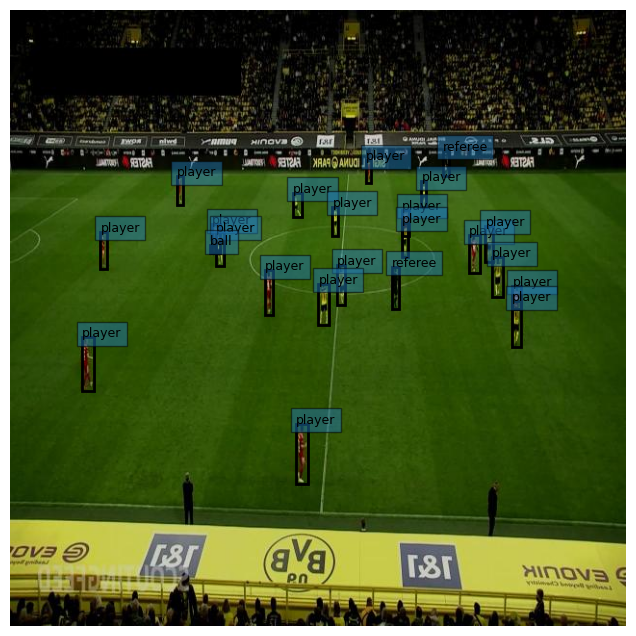

In [46]:
split = "train"
images_dir = (dataset_path/ split/ "images")
labels_dir = (dataset_path/ split/ "labels")
image_path = random.choice(list(images_dir.glob("*.jpg")))
label_path = (labels_dir/ f"{image_path.stem}.txt")
plot_yolo_image(image_path,label_path,class_names)

# 3. Preprocesamiento

In [47]:
splits = ["train", "valid", "test"]
valid_ext = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp"}

yaml_path = dataset_path / "data.yaml"
with open(yaml_path, "r") as f:
    data_yaml = yaml.safe_load(f)

class_names = data_yaml["names"]
nc = data_yaml["nc"]

print("Número de clases:", nc)
print("Clases:", class_names)

Número de clases: 4
Clases: ['ball', 'goalkeeper', 'player', 'referee']


In [48]:
inventory = []
unmatched = []

for split in splits:
    images_dir = dataset_path / split / "images"
    labels_dir = dataset_path / split / "labels"

    images = [p for p in images_dir.iterdir() if p.suffix.lower() in valid_ext]
    labels = list(labels_dir.glob("*.txt"))

    images_by_stem = {p.stem: p for p in images}
    labels_by_stem = {p.stem: p for p in labels}

    image_stems = set(images_by_stem)
    label_stems = set(labels_by_stem)

    only_images = sorted(image_stems - label_stems)
    only_labels = sorted(label_stems - image_stems)

    inventory.append({
        "split": split,
        "images": len(images),
        "labels": len(labels),
        "images_without_label": len(only_images),
        "labels_without_image": len(only_labels),
    })

    for stem in only_images:
        unmatched.append({"split": split, "type": "image_without_label", "stem": stem})
    for stem in only_labels:
        unmatched.append({"split": split, "type": "label_without_image", "stem": stem})

df_inventory = pd.DataFrame(inventory)
display(df_inventory)

print("Total de archivos sin pareja:", len(unmatched))

,split,images,labels,images_without_label,labels_without_image
0,train,46511,46511,0,0
1,valid,4757,4757,0,0
2,test,2177,2177,0,0


Total de archivos sin pareja: 0


In [49]:
empty_labels = []

for split in splits:
    labels_dir = dataset_path / split / "labels"

    for label_path in labels_dir.glob("*.txt"):
        if label_path.stat().st_size == 0:
            empty_labels.append({
                "split": split,
                "label": label_path.name
            })

df_empty = pd.DataFrame(empty_labels)

print("Labels vacíos totales:", len(df_empty))
display(df_empty["split"].value_counts().rename("labels_vacios").to_frame())

print(f"Porcentaje sobre el total de imágenes: {100 * len(df_empty) / df_inventory['images'].sum():.2f}%")

Labels vacíos totales: 2620


,labels_vacios
split,
train,2162
valid,317
test,141


Porcentaje sobre el total de imágenes: 4.90%


## Validación de anotaciones correctas (bounding box correctos)

In [50]:
from collections import Counter, defaultdict
import math

In [51]:
def validate_yolo_line(line, nc, tol=1e-6):
    parts = line.strip().split()

    if len(parts) != 5:
        return False, "cantidad_columnas"

    try:
        cls_f, x, y, w, h = map(float, parts)
    except ValueError:
        return False, "valor_no_numerico"

    vals = [cls_f, x, y, w, h]
    if not all(math.isfinite(v) for v in vals):
        return False, "valor_no_finito"

    cls = int(cls_f)
    if cls_f != cls or not (0 <= cls < nc):
        return False, "class_id_invalido"

    if not (0 <= x <= 1 and 0 <= y <= 1):
        return False, "centro_fuera_rango"

    if not (0 < w <= 1 and 0 < h <= 1):
        return False, "tamano_bbox_invalido"

    # Validación adicional: bordes del bbox dentro de la imagen.
    x1, x2 = x - w / 2, x + w / 2
    y1, y2 = y - h / 2, y + h / 2

    if x1 < -tol or y1 < -tol or x2 > 1 + tol or y2 > 1 + tol:
        return False, "bbox_fuera_imagen"

    return True, "ok"


invalid_annotations = []
duplicate_annotation_lines = []
label_stats = []

for split in splits:
    labels_dir = dataset_path / split / "labels"

    for label_path in tqdm(list(labels_dir.glob("*.txt")), desc=f"Labels {split}"):
        with open(label_path, "r") as f:
            raw_lines = [line.strip() for line in f if line.strip()]

        counts = Counter(raw_lines)
        for line, count in counts.items():
            if count > 1:
                duplicate_annotation_lines.append({
                    "split": split,
                    "label": label_path.name,
                    "line": line,
                    "repeticiones": count
                })

        n_valid = 0
        n_invalid = 0

        for line_number, line in enumerate(raw_lines, start=1):
            ok, reason = validate_yolo_line(line, nc)

            if ok:
                n_valid += 1
            else:
                n_invalid += 1
                invalid_annotations.append({
                    "split": split,
                    "label": label_path.name,
                    "line_number": line_number,
                    "line": line,
                    "reason": reason
                })

        label_stats.append({
            "split": split,
            "label": label_path.name,
            "valid_objects": n_valid,
            "invalid_objects": n_invalid,
            "empty": len(raw_lines) == 0
        })

df_label_stats = pd.DataFrame(label_stats)
df_invalid = pd.DataFrame(invalid_annotations)
df_dup_lines = pd.DataFrame(duplicate_annotation_lines)

print("Anotaciones inválidas:", len(df_invalid))
print("Archivos con líneas duplicadas:", df_dup_lines["label"].nunique() if len(df_dup_lines) else 0)

if len(df_invalid):
    display(df_invalid["reason"].value_counts().to_frame())
    display(df_invalid.head(20))

Labels train:   0%|          | 0/46511 [00:00<?, ?it/s]

Labels valid:   0%|          | 0/4757 [00:00<?, ?it/s]

Labels test:   0%|          | 0/2177 [00:00<?, ?it/s]

Anotaciones inválidas: 39
Archivos con líneas duplicadas: 7


,count
reason,
cantidad_columnas,39


,split,label,line_number,line,reason
0,train,ds12_411_jpg.rf.329c9e77afedb105881a0dd1aa1bc5...,1,2 0.519078125 0.5744351851851852 0.51991145833...,cantidad_columnas
1,train,ds12_274_jpg.rf.99bb0c66d0c2bb7c001959eda1ee09...,1,2 0 0.9990740740740741 0.011041666666666667 0....,cantidad_columnas
2,train,ds12_333_jpg.rf.96615ae9312a6cfbd5ce04aa30f73b...,1,2 0.298859375 0.45433333333333337 0.2982291666...,cantidad_columnas
3,train,ds12_350_jpg.rf.af0faaccf136db4d65bf6318118462...,1,2 0.3613489583333333 0.39273148148148146 0.361...,cantidad_columnas
4,train,ds12_414_jpg.rf.5eb887f89ebfe9c753622d0b0c47df...,1,2 0.8182760416666667 0.5588240740740741 0.8181...,cantidad_columnas
5,train,ds12_414_jpg.rf.5eb887f89ebfe9c753622d0b0c47df...,2,2 0.7459114583333334 0.6157037037037038 0.7458...,cantidad_columnas
6,train,ds12_414_jpg.rf.5eb887f89ebfe9c753622d0b0c47df...,3,2 0.699515625 0.5990555555555556 0.69965104166...,cantidad_columnas
7,train,ds12_412_jpg.rf.7252015ca02951f7e789a235773087...,1,2 0.6980572916666666 0.6167314814814815 0.6975...,cantidad_columnas
8,train,ds12_114_jpg.rf.3209f3bd67de1c00ae54c37444383c...,1,2 0.7008333333333333 0.4109259259259259 0.7006...,cantidad_columnas
9,train,ds12_393_jpg.rf.f02919d9d4904c559eaa7beb2278ff...,1,2 0.35984374999999996 0.2612962962962963 0.360...,cantidad_columnas


## Imágenes corruptas

In [52]:
corrupted_images = []

for split in splits:
    images_dir = dataset_path / split / "images"
    image_files = [p for p in images_dir.iterdir() if p.suffix.lower() in valid_ext]

    for img_path in tqdm(image_files, desc=f"Imágenes {split}"):
        try:
            with Image.open(img_path) as img:
                img.verify()
        except Exception as e:
            corrupted_images.append({
                "split": split,
                "image": img_path.name,
                "error": str(e)
            })

df_corrupted = pd.DataFrame(corrupted_images)

print("Imágenes corruptas:", len(df_corrupted))
if len(df_corrupted):
    display(df_corrupted.head(20))

Imágenes train:   0%|          | 0/46511 [00:00<?, ?it/s]

Imágenes valid:   0%|          | 0/4757 [00:00<?, ?it/s]

Imágenes test:   0%|          | 0/2177 [00:00<?, ?it/s]

Imágenes corruptas: 0


## Base Limpia

In [53]:
import shutil

In [54]:
clean_root = Path("/content/football_clean")

if clean_root.exists():
    shutil.rmtree(clean_root)

for split in splits:
    (clean_root / split / "images").mkdir(parents=True, exist_ok=True)
    (clean_root / split / "labels").mkdir(parents=True, exist_ok=True)

corrupt_set = set()
if len(df_corrupted):
    corrupt_set = {(r["split"], r["image"]) for _, r in df_corrupted.iterrows()}

invalid_by_label = defaultdict(set)
if len(df_invalid):
    for _, r in df_invalid.iterrows():
        invalid_by_label[(r["split"], r["label"])].add(int(r["line_number"]))

clean_report = []

def link_or_copy(src, dst):
    try:
        os.link(src, dst)
    except OSError:
        shutil.copy2(src, dst)

for split in splits:
    src_images = dataset_path / split / "images"
    src_labels = dataset_path / split / "labels"

    dst_images = clean_root / split / "images"
    dst_labels = clean_root / split / "labels"

    images_by_stem = {
        p.stem: p
        for p in src_images.iterdir()
        if p.suffix.lower() in valid_ext
    }
    labels_by_stem = {p.stem: p for p in src_labels.glob("*.txt")}

    common_stems = sorted(set(images_by_stem) & set(labels_by_stem))

    copied = 0
    skipped_corrupt = 0
    removed_invalid_lines = 0
    removed_duplicate_lines = 0

    for stem in tqdm(common_stems, desc=f"Construyendo {split}"):
        img_path = images_by_stem[stem]
        label_path = labels_by_stem[stem]

        if (split, img_path.name) in corrupt_set:
            skipped_corrupt += 1
            continue

        with open(label_path, "r") as f:
            raw_lines = [line.strip() for line in f if line.strip()]

        cleaned_lines = []
        seen = set()

        for line in raw_lines:
            ok, _ = validate_yolo_line(line, nc)

            if not ok:
                removed_invalid_lines += 1
                continue

            # Eliminar anotaciones idénticas duplicadas dentro del mismo archivo.
            if line in seen:
                removed_duplicate_lines += 1
                continue

            seen.add(line)
            cleaned_lines.append(line)

        link_or_copy(img_path, dst_images / img_path.name)

        with open(dst_labels / f"{stem}.txt", "w") as f:
            if cleaned_lines:
                f.write("\n".join(cleaned_lines) + "\n")
            # Si estaba vacío se conserva como background.

        copied += 1

    clean_report.append({
        "split": split,
        "pares_copiados": copied,
        "imagenes_corruptas_omitidas": skipped_corrupt,
        "lineas_invalidas_eliminadas": removed_invalid_lines,
        "lineas_duplicadas_eliminadas": removed_duplicate_lines,
    })

df_clean_report = pd.DataFrame(clean_report)
display(df_clean_report)

Construyendo train:   0%|          | 0/46511 [00:00<?, ?it/s]

Construyendo valid:   0%|          | 0/4757 [00:00<?, ?it/s]

Construyendo test:   0%|          | 0/2177 [00:00<?, ?it/s]

,split,pares_copiados,imagenes_corruptas_omitidas,lineas_invalidas_eliminadas,lineas_duplicadas_eliminadas
0,train,46511,0,37,162
1,valid,4757,0,2,0
2,test,2177,0,0,0


In [55]:
clean_yaml = {
    "path": str(clean_root),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": nc,
    "names": class_names,
}

with open(clean_root / "data.yaml", "w") as f:
    yaml.safe_dump(clean_yaml, f, sort_keys=False)

print((clean_root / "data.yaml").read_text())

path: /content/football_clean
train: train/images
val: valid/images
test: test/images
nc: 4
names:
- ball
- goalkeeper
- player
- referee



In [56]:
final_summary = []

for split in splits:
    images_dir = clean_root / split / "images"
    labels_dir = clean_root / split / "labels"

    images = [p for p in images_dir.iterdir() if p.suffix.lower() in valid_ext]
    labels = list(labels_dir.glob("*.txt"))
    empty = sum(p.stat().st_size == 0 for p in labels)

    final_summary.append({
        "split": split,
        "images": len(images),
        "labels": len(labels),
        "empty_labels": empty,
    })

df_final = pd.DataFrame(final_summary)
display(df_final)

assert (df_final["images"] == df_final["labels"]).all(), "Hay diferencias imagen-label en la base limpia."

print("Base limpia creada en:", clean_root)
print("YAML:", clean_root / "data.yaml")

,split,images,labels,empty_labels
0,train,46511,46511,2163
1,valid,4757,4757,317
2,test,2177,2177,141


Base limpia creada en: /content/football_clean
YAML: /content/football_clean/data.yaml


# 4. Modelo

In [57]:
!pip -q install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 10.7 MB/s eta 0:00:00


## Muestreo Estratificado por Segemento (20%)

In [58]:
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict, Counter


def build_stratified_sample(
    clean_root,
    split="train",
    fraction=0.2
):

    valid_ext = {
        ".jpg",
        ".jpeg",
        ".png",
        ".bmp",
        ".tiff",
        ".webp"
    }

    images_dir = (
        Path(clean_root)
        / split
        / "images"
    )

    labels_dir = (
        Path(clean_root)
        / split
        / "labels"
    )

    # ------------------------------------------
    # 1. Relacionar imágenes con labels
    # ------------------------------------------

    images_by_stem = {
        p.stem: p
        for p in images_dir.iterdir()
        if p.suffix.lower() in valid_ext
    }

    labels_by_stem = {
        p.stem: p
        for p in labels_dir.glob("*.txt")
    }

    stems = sorted(
        set(images_by_stem)
        & set(labels_by_stem)
    )

    # ------------------------------------------
    # 2. Obtener clases presentes por imagen
    # ------------------------------------------

    strata = defaultdict(list)

    for stem in stems:

        classes = set()

        with open(
            labels_by_stem[stem],
            "r"
        ) as f:

            for line in f:

                parts = line.strip().split()

                if len(parts) == 5:

                    class_id = int(
                        float(parts[0])
                    )

                    classes.add(class_id)

        # Label vacío
        if len(classes) == 0:

            stratum = "empty"

        else:

            # Ejemplo:
            # (0,2) -> ball + player
            stratum = tuple(
                sorted(classes)
            )

        strata[stratum].append(stem)

    # ------------------------------------------
    # 3. Tamaño total deseado
    # ------------------------------------------

    target_total = round(
        len(stems) * fraction
    )

    print(
        f"Train original: {len(stems):,}"
    )

    print(
        f"Objetivo ({fraction:.0%}): "
        f"{target_total:,} imágenes"
    )

    # ------------------------------------------
    # 4. Cuotas proporcionales por segmento
    # ------------------------------------------

    quotas_float = {}

    for stratum, items in strata.items():

        quotas_float[stratum] = (
            len(items)
            / len(stems)
            * target_total
        )

    # Parte entera
    quotas = {
        s: int(np.floor(q))
        for s, q in quotas_float.items()
    }

    # ------------------------------------------
    # 5. Ajustar para obtener exactamente 5%
    # ------------------------------------------

    assigned = sum(
        quotas.values()
    )

    remaining = (
        target_total
        - assigned
    )

    # Mayor residuo decimal
    remainders = sorted(
        quotas_float.keys(),
        key=lambda s:
            quotas_float[s]
            - quotas[s],
        reverse=True
    )

    for stratum in remainders[:remaining]:

        quotas[stratum] += 1

    # ------------------------------------------
    # 6. Selección NO aleatoria
    # ------------------------------------------

    sample_stems = []

    summary = []

    for stratum, items in sorted(
        strata.items(),
        key=lambda x: str(x[0])
    ):

        items = sorted(items)

        n_total = len(items)

        n_sample = quotas[stratum]

        if n_sample > 0:

            # posiciones uniformemente espaciadas
            indices = np.linspace(
                0,
                n_total - 1,
                num=n_sample,
                dtype=int
            )

            selected = [
                items[i]
                for i in indices
            ]

        else:

            selected = []

        sample_stems.extend(
            selected
        )

        summary.append({
            "segmento": str(stratum),
            "total_train": n_total,
            "muestra": len(selected),
            "porcentaje": (
                len(selected)
                / n_total
                * 100
                if n_total > 0
                else 0
            )
        })

    df_summary = pd.DataFrame(
        summary
    )

    print()
    print(
        f"Muestra final: "
        f"{len(sample_stems):,}"
    )

    print(
        f"Porcentaje final: "
        f"{len(sample_stems)/len(stems):.2%}"
    )

    return (
        set(sample_stems),
        images_by_stem,
        labels_by_stem,
        df_summary
    )

In [59]:
sample_stems, images_by_stem, labels_by_stem, df_segments = (
    build_stratified_sample(
        clean_root,
        split="train",
        fraction=0.2
    )
)

Train original: 46,511
Objetivo (20%): 9,302 imágenes

Muestra final: 9,302
Porcentaje final: 20.00%


In [60]:
df_segments

,segmento,total_train,muestra,porcentaje
0,"(0, 1)",8,2,25.000000
1,"(0, 1, 2)",738,148,20.054201
2,"(0, 1, 2, 3)",15787,3157,19.997466
3,"(0, 2)",7962,1592,19.994976
4,"(0, 2, 3)",9662,1932,19.995860
5,"(0,)",17,3,17.647059
6,"(1, 2)",210,42,20.000000
7,"(1, 2, 3)",3078,616,20.012995
8,"(1,)",30,6,20.000000
9,"(2, 3)",5112,1022,19.992175


In [61]:
class_names = {
    0: "ball",
    1: "goalkeeper",
    2: "player",
    3: "referee"
}

In [62]:
def segment_name(segment):

    if segment == "empty":
        return "empty"

    return " + ".join(
        class_names[c]
        for c in segment
    )

In [63]:
df_segments["segmento_nombre"] = (
    df_segments["segmento"]
)

In [64]:
def materialize_sample(
    sample_stems,
    images_by_stem,
    labels_by_stem,
    out_root,
    split="train"
):

    out_images = (
        Path(out_root)
        / split
        / "images"
    )

    out_labels = (
        Path(out_root)
        / split
        / "labels"
    )

    out_images.mkdir(
        parents=True,
        exist_ok=True
    )

    out_labels.mkdir(
        parents=True,
        exist_ok=True
    )

    def link_or_copy(src, dst):

        try:
            os.link(src, dst)

        except OSError:
            shutil.copy2(src, dst)

    for stem in sample_stems:

        link_or_copy(
            images_by_stem[stem],
            out_images
            / images_by_stem[stem].name
        )

        link_or_copy(
            labels_by_stem[stem],
            out_labels
            / labels_by_stem[stem].name
        )

In [65]:
sample_root = Path(
    "/content/football_sample"
)

if sample_root.exists():
    shutil.rmtree(
        sample_root
    )

materialize_sample(
    sample_stems,
    images_by_stem,
    labels_by_stem,
    sample_root,
    split="train"
)

In [66]:
sample_yaml = {
    "path": str(sample_root),

    "train": "train/images",

    "val": str(
        (
            clean_root
            / "valid"
            / "images"
        ).resolve()
    ),

    "test": str(
        (
            clean_root
            / "test"
            / "images"
        ).resolve()
    ),

    "nc": nc,
    "names": class_names,
}

In [71]:
print(
    (sample_root / "data.yaml").read_text()
)

path: /content/football_sample
train: train/images
val: /content/football_clean/valid/images
test: /content/football_clean/test/images
nc: 4
names:
- ball
- goalkeeper
- player
- referee



## YOLO11

In [73]:
from ultralytics import YOLO

model = YOLO("yolo11s.pt")

results = model.train(
    data=str(
        sample_root / "data.yaml"
    ),
    epochs=30,
    patience=5,
    imgsz=640,
    batch=-1,
    workers=2,
    cache=False,
    plots=False,
    device=0,
    project="/content/runs",
    name="football_yolo11s_5pct",
    exist_ok=True,
    seed=42,
    deterministic=True
)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/football_sample/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=

## Guardar el Modelo

In [74]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [75]:
import shutil

origen = (
    "/content/runs/"
    "football_yolo11s_5pct/"
    "weights/best.pt"
)

destino = (
    "/content/drive/MyDrive/"
    "modelos_yolo/"
    "football_yolo11s_5pct_best.pt"
)

from pathlib import Path

Path(destino).parent.mkdir(
    parents=True,
    exist_ok=True
)

shutil.copy2(
    origen,
    destino
)

print("Modelo guardado en:")
print(destino)

Modelo guardado en:
/content/drive/MyDrive/modelos_yolo/football_yolo11s_5pct_best.pt


In [76]:
from ultralytics import YOLO

modeltest = YOLO(
    "/content/drive/MyDrive/"
    "modelos_yolo/"
    "football_yolo11s_5pct_best.pt"
)

## Mejor Modelo

In [77]:
from ultralytics import YOLO
from pathlib import Path

best_path = Path(
    "/content/runs/football_yolo11s_5pct/weights/best.pt"
)

print("¿Existe best.pt?:", best_path.exists())
print("Ruta:", best_path)

best_model = YOLO(str(best_path))

¿Existe best.pt?: True
Ruta: /content/runs/football_yolo11s_5pct/weights/best.pt


# 5. Evaluación sobre VALID

In [78]:
metrics_val = best_model.val(
    data=str(sample_root / "data.yaml"),
    split="val",
    imgsz=640,
    device=0,
    plots=True,
    project="/content/runs_eval",
    name="football_yolo11s_val"
)

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 100 layers, 9,414,348 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2275.5±1133.0 MB/s, size: 97.2 KB)
val: Scanning /content/football_clean/valid/labels.cache... 4757 images, 317 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4757/4757 1.2Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 298/298 3.9it/s 1:17
                   all       4757      82441      0.785      0.758      0.714      0.452
                  ball       3497       3522      0.775      0.479      0.512      0.234
            goalkeeper       1865       2028      0.696      0.786      0.673      0.433
                player       4431      70703      0.943      0.929      0.972      0.709
               referee       2958       6188      0.725      0.837        0.7      0.432
Speed: 0.7ms preprocess, 11.2m

In [79]:
print("mAP@50:", metrics_val.box.map50)
print("mAP@50-95:", metrics_val.box.map)
print("mAP@75:", metrics_val.box.map75)

mAP@50: 0.7141823499854694
mAP@50-95: 0.4520475223375984
mAP@75: 0.48923112366937305


## Evaluación por cada clase por separado

In [80]:
import pandas as pd

names = best_model.names

df_metrics = pd.DataFrame({
    "class_id": range(len(metrics_val.box.maps)),
    "class_name": [
        names[i]
        for i in range(len(metrics_val.box.maps))
    ],
    "mAP50-95": metrics_val.box.maps
})

df_metrics

,class_id,class_name,mAP50-95
0,0,ball,0.233855
1,1,goalkeeper,0.433377
2,2,player,0.708528
3,3,referee,0.432430


In [81]:
df_metrics["precision"] = metrics_val.box.p
df_metrics["recall"] = metrics_val.box.r

df_metrics

,class_id,class_name,mAP50-95,precision,recall
0,0,ball,0.233855,0.775432,0.478989
1,1,goalkeeper,0.433377,0.696499,0.785503
2,2,player,0.708528,0.943282,0.929310
3,3,referee,0.432430,0.724912,0.836619


## Matriz de confusión

In [82]:
from pathlib import Path

eval_dir = Path(
    "/content/runs_eval/football_yolo11s_val"
)

for file in eval_dir.iterdir():
    print(file.name)

BoxPR_curve.png
BoxF1_curve.png
val_batch2_labels.jpg
val_batch1_pred.jpg
BoxP_curve.png
val_batch2_pred.jpg
confusion_matrix_normalized.png
val_batch0_pred.jpg
val_batch0_labels.jpg
confusion_matrix.png
BoxR_curve.png
val_batch1_labels.jpg


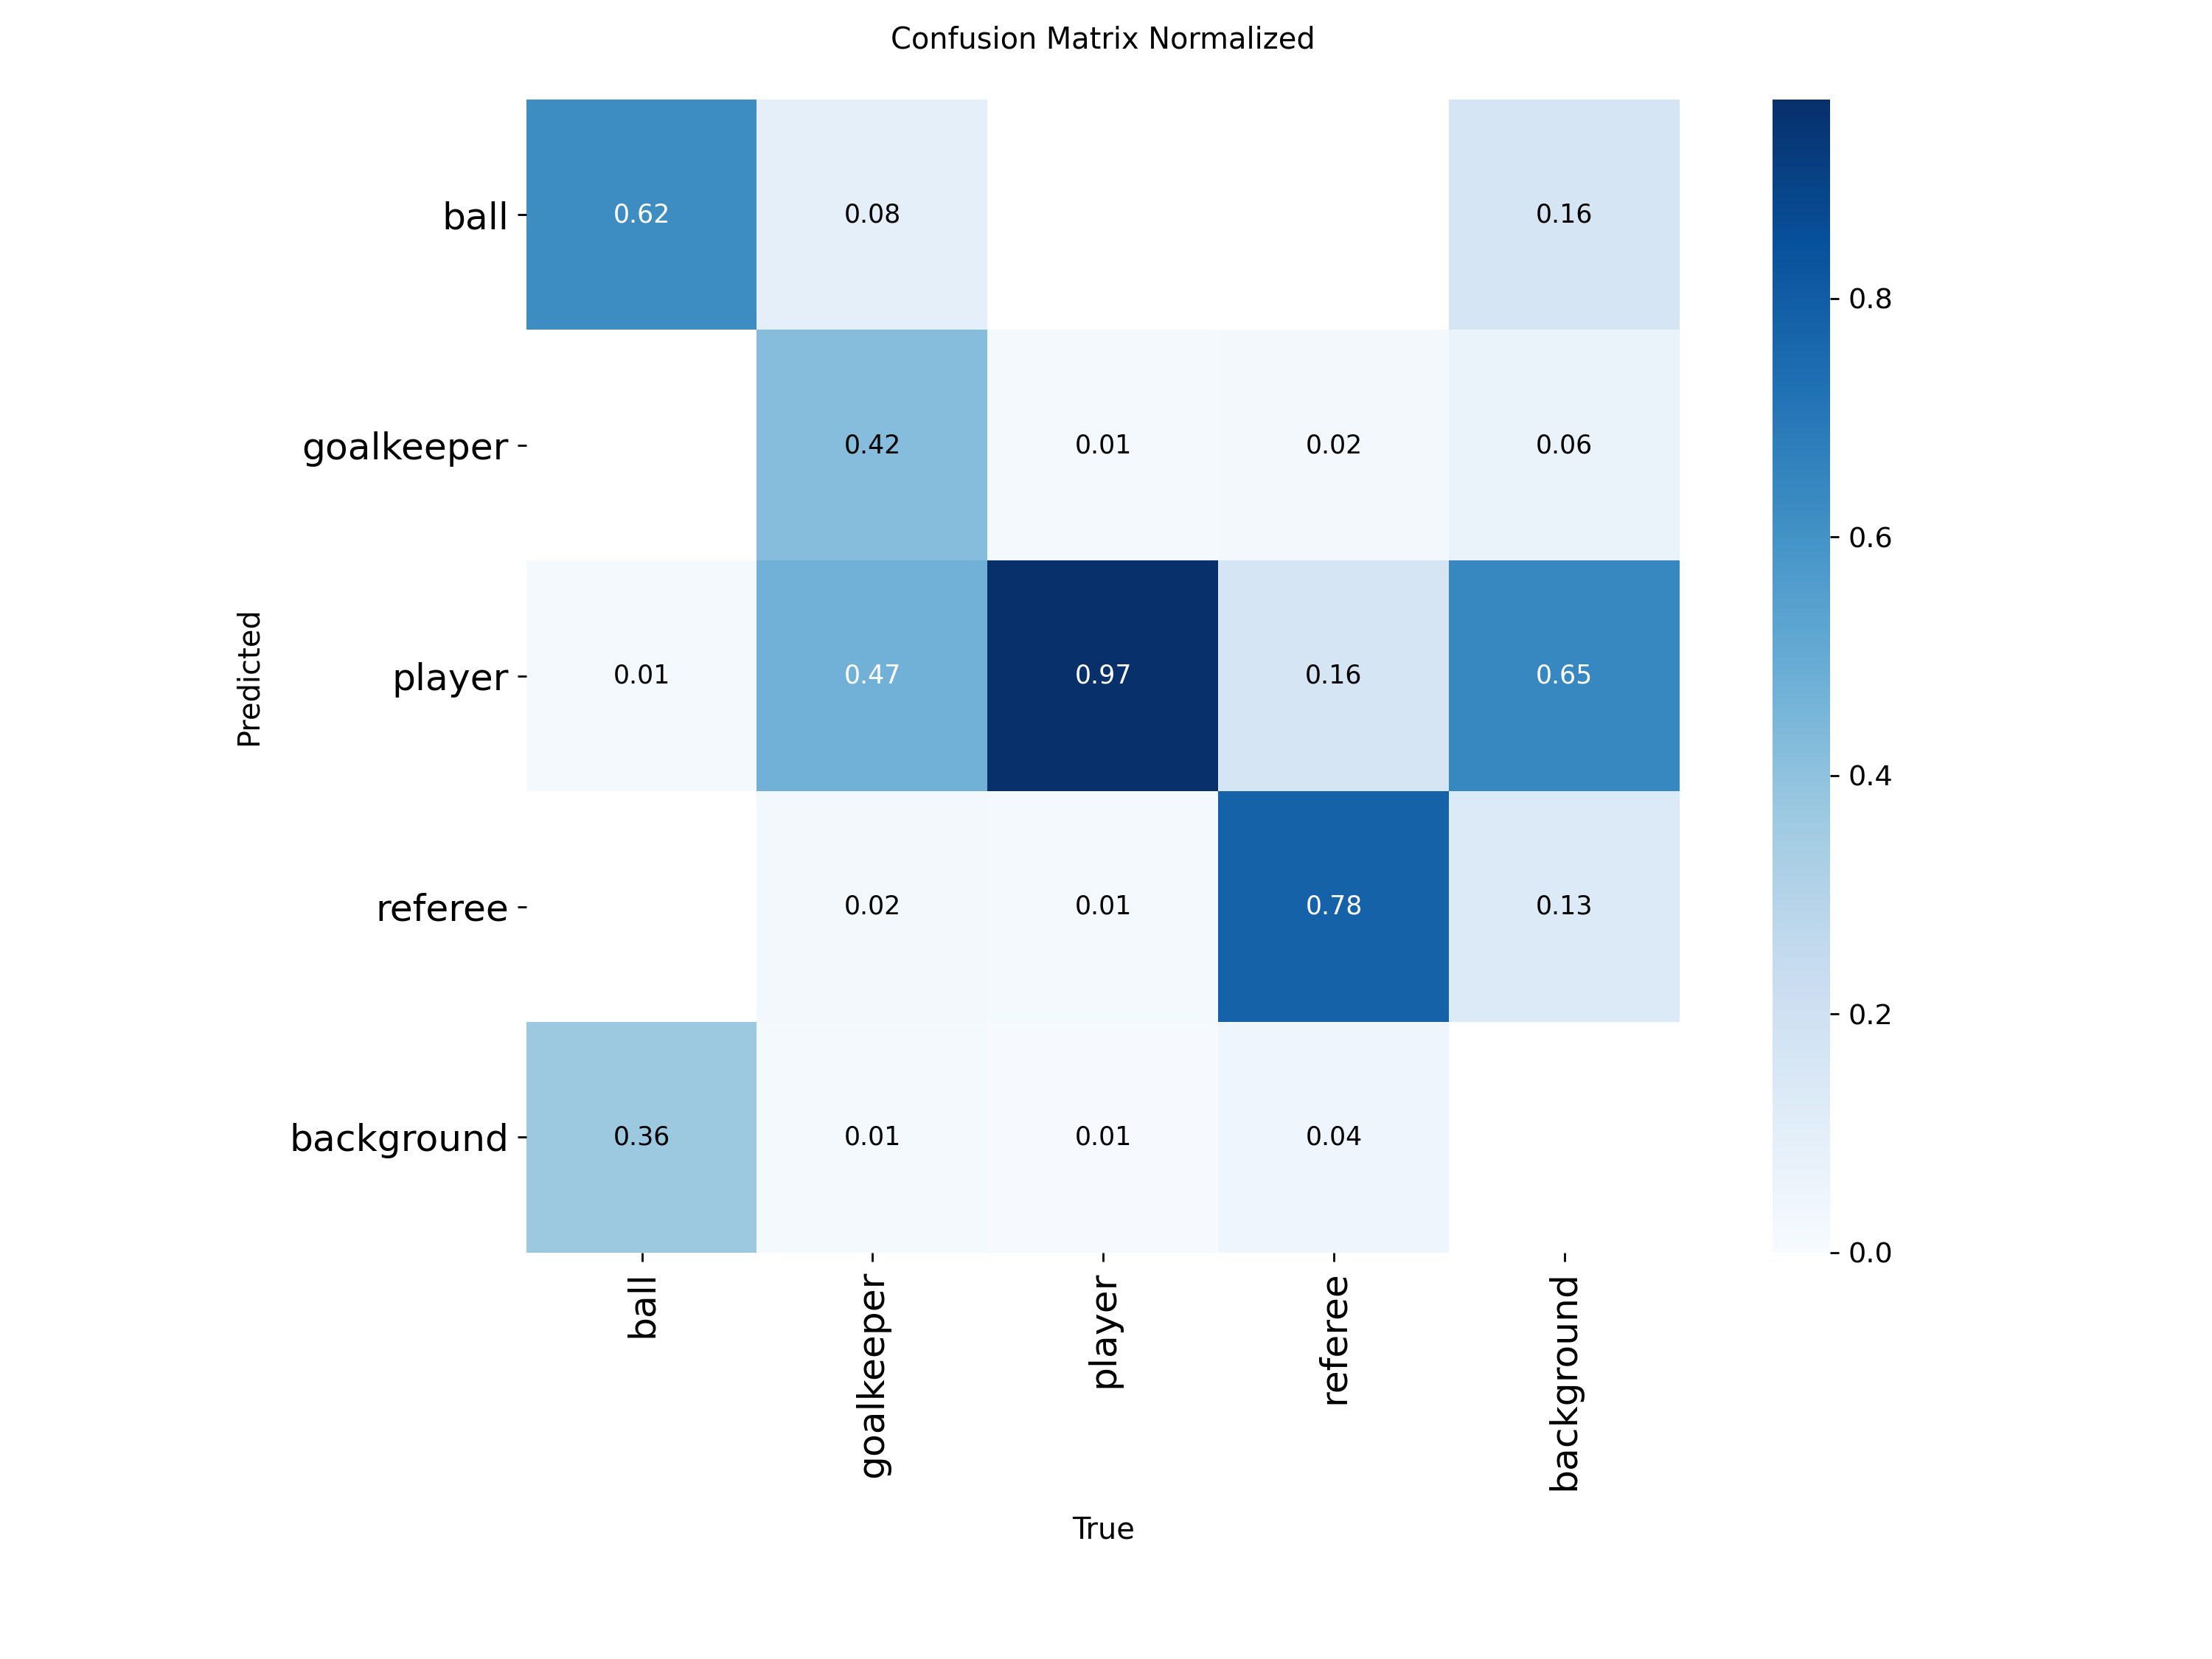

In [83]:
from IPython.display import Image, display

display(
    Image(
        filename=str(
            eval_dir /
            "confusion_matrix_normalized.png"
        )
    )
)

# 6. Evaluación sobre el Test

In [84]:
metrics_test = best_model.val(
    data=str(sample_root / "data.yaml"),
    split="test",
    imgsz=640,
    device=0,
    plots=True,
    project="/content/runs_eval",
    name="football_yolo11s_test"
)

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 100 layers, 9,414,348 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1171.6±284.5 MB/s, size: 55.4 KB)
val: Scanning /content/football_clean/test/labels... 2177 images, 141 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2177/2177 1.2Kit/s 1.9s
val: New cache created: /content/football_clean/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 137/137 3.7it/s 37.2s
                   all       2177      37461      0.768      0.734      0.678      0.419
                  ball       1529       1555      0.771      0.464      0.482      0.216
            goalkeeper        886        959      0.675      0.806      0.677      0.428
                player       2032      31905      0.932      0.926      0.958      0.674
               referee       1299       3042      0.693     

In [85]:
print("TEST")
print("-------------------------")
print("mAP@50:", metrics_test.box.map50)
print("mAP@50-95:", metrics_test.box.map)
print("mAP@75:", metrics_test.box.map75)

TEST
-------------------------
mAP@50: 0.6776993186509719
mAP@50-95: 0.41863165521498447
mAP@75: 0.4379741760707524


# 7. Posprocedimiento

No se necesita implementar NMS desde cero. YOLO ya lo incorpora en la inferencia.

# 8. Prueba con una imagen

In [87]:
import random

test_images = list(
    (clean_root / "test" / "images").glob("*.jpg")
)

img_test = random.choice(test_images)

print(img_test)

/content/football_clean/test/images/ds49_798b45_3_10_png_jpg.rf.816ba02aaf641247cb027c391012bd62.jpg


In [88]:
result = best_model.predict(
    source=str(img_test),
    imgsz=640,
    conf=0.25,
    iou=0.7,
    device=0,
    save=True
)


image 1/1 /content/football_clean/test/images/ds49_798b45_3_10_png_jpg.rf.816ba02aaf641247cb027c391012bd62.jpg: 640x640 2 balls, 21 players, 2 referees, 24.1ms
Speed: 1.3ms preprocess, 24.1ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


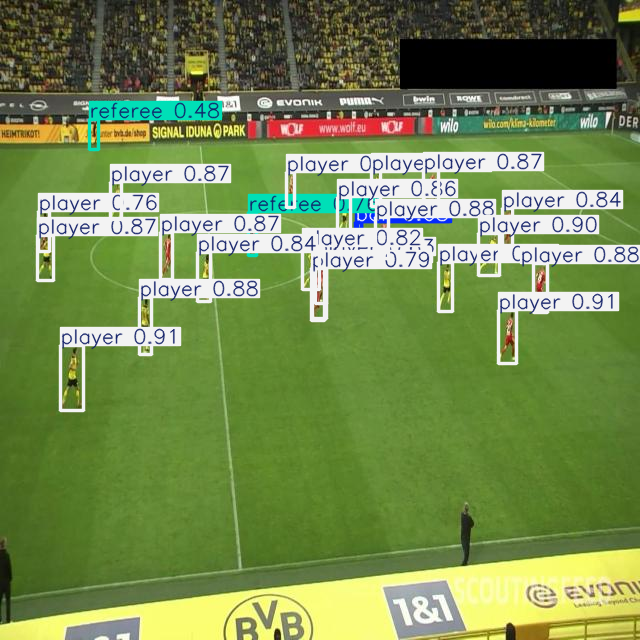

In [89]:
result[0].show()

# 9. Prueba con un Video

In [90]:
from google.colab import files

uploaded = files.upload()

Saving video_futbol2.mp4 to video_futbol2.mp4


In [91]:
video_results = best_model.predict(
    source="/content/video_futbol2.mp4",
    imgsz=640,
    conf=0.25,
    iou=0.7,
    device=0,
    save=True,
    project="/content/video_results",
    name="deteccion_partido"
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/2250) /content/video_futbol2.mp4: 384x640 3 goalkeepers, 4 players, 52.7ms
video 1/1 (frame 2/2250) /content/video_futbol2.mp4: 384x640 2 goalkeepers, 4 players, 16.0ms
video 1/1 (frame 3/2250) /content/video_futbol2.mp4: 384x640 2 goalkeepers, 3 players, 16.0ms
video 1/1 (frame 4/2250) /content/video_futbol2.mp4: 384x640 2 goalkeepers, 2 players, 16.0ms
video 1/1 (frame 5/2250) /content/video_futbol2.mp4: 384x640 2 goalkeepers, 3 playe